Objectives:
Performs extensive data analysis to identify interdependencies between various hydrological variables (e.g. precipitation, snowmelt, temperature, groundwater level) and the target variable, which is inflow to Sogndalsvatn.

Creates new time series-based features, performs stationarity analysis, and uses decomposition techniques (e.g. seasonal decomposition, trend analysis).

Develops forecasting models to predict future inflow to Sogndalsvatn.

In [55]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [56]:
df = pd.read_csv('dataset_Sogndalsvatn.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.head()

,gwb_sssrel1,gwb_sssrel2,gwb_sssrel3,gwb_sssrel4,lwc1,lwc2,lwc3,lwc4,qsw1,qsw2,...,rr4,swe1,swe2,swe3,swe4,tm1,tm2,tm3,tm4,inflow
Date,,,,,,,,,,,,,,,,,,,,,
2000-06-22,62.0,98,64,62.0,0.0,9.9,9.9,9.9,0,25,...,1.5,0.0,1548.9,906.1,1540.7,12.7,7.9,9.7,7.8,1.911599
2000-06-23,60.0,98,63,61.0,0.0,9.9,9.9,9.9,0,19,...,3.4,0.0,1528.2,880.8,1520.4,11.9,4.5,7.1,4.5,1.888370
2000-06-24,58.0,98,61,60.0,0.0,9.9,9.9,9.9,0,17,...,0.1,0.0,1506.8,854.5,1499.3,12.5,3.5,6.2,3.5,1.808743
2000-06-25,56.0,98,60,60.0,0.0,9.9,9.9,9.9,0,18,...,0.0,0.0,1486.9,828.9,1479.4,12.0,3.7,6.2,3.6,1.818097
2000-06-26,54.0,98,58,59.0,0.0,9.9,9.9,9.9,0,16,...,0.0,0.0,1469.7,806.5,1462.1,11.2,2.9,5.7,2.9,1.788487


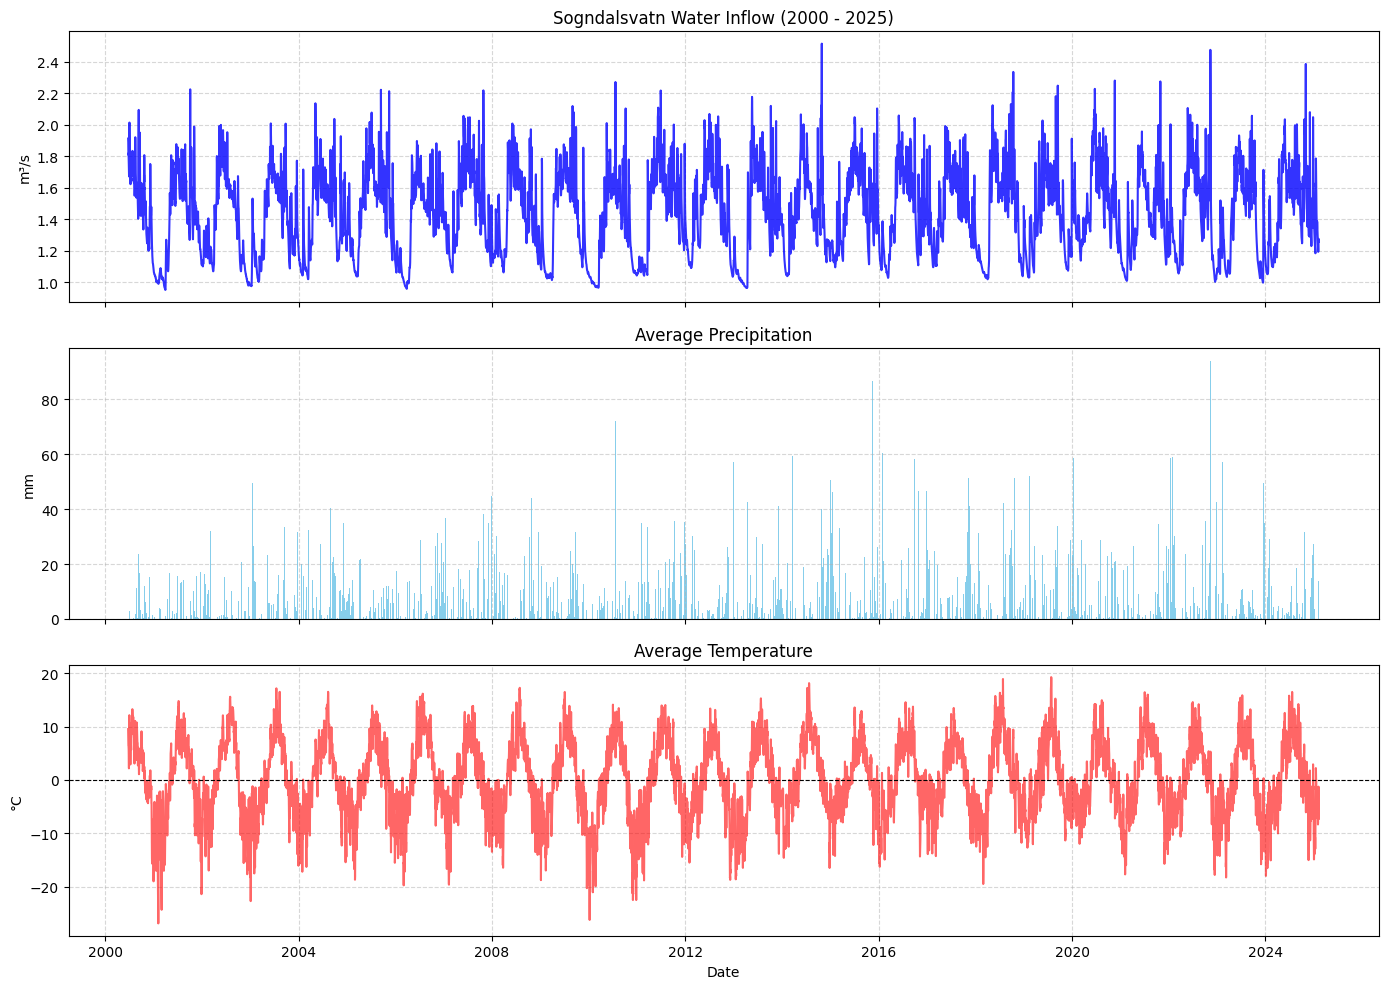

In [57]:
df['Inflow'] = df['inflow']
df['Precipitation'] = df[['rr1', 'rr2', 'rr3', 'rr4']].mean(axis=1)
df['Temperature'] = df[['tm1', 'tm2', 'tm3', 'tm4']].mean(axis=1)

# 3. Plot the complete timeline
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Inflow
axes[0].plot(df.index, df['Inflow'], color='blue', alpha=0.8)
axes[0].set_title('Sogndalsvatn Water Inflow (2000 - 2025)')
axes[0].set_ylabel('m³/s')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Precipitation
axes[1].bar(df.index, df['Precipitation'], color='skyblue', width=1.0)
axes[1].set_title('Average Precipitation')
axes[1].set_ylabel('mm')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Temperature
axes[2].plot(df.index, df['Temperature'], color='red', alpha=0.6)
axes[2].axhline(0, color='black', linestyle='--', linewidth=0.8) # Freezing point
axes[2].set_title('Average Temperature')
axes[2].set_ylabel('°C')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

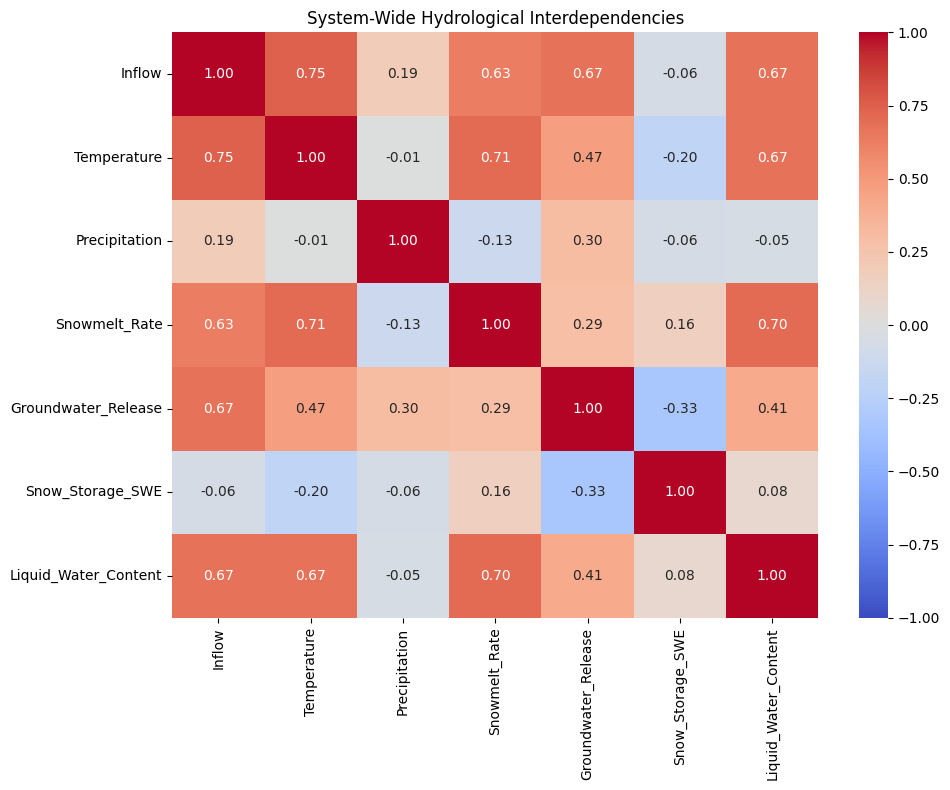

In [58]:
# 1. Create the remaining catchment-scale aggregates (Precipitation and Temperature are already handled)
df['Snowmelt_Rate'] = df[['qsw1', 'qsw2', 'qsw3', 'qsw4']].mean(axis=1)
df['Groundwater_Release'] = df[['gwb_sssrel1', 'gwb_sssrel2', 'gwb_sssrel3', 'gwb_sssrel4']].mean(axis=1)
df['Snow_Storage_SWE'] = df[['swe1', 'swe2', 'swe3', 'swe4']].mean(axis=1)
df['Liquid_Water_Content'] = df[['lwc1', 'lwc2', 'lwc3', 'lwc4']].mean(axis=1)

# 2. Select variables for interdependence analysis (Using 'Inflow' to match your clean target column name)
system_features = [
    'Inflow', 'Temperature', 'Precipitation', 
    'Snowmelt_Rate', 'Groundwater_Release', 'Snow_Storage_SWE', 'Liquid_Water_Content'
]

# 3. Generate the correlation matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[system_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('System-Wide Hydrological Interdependencies')
plt.tight_layout()
plt.show()

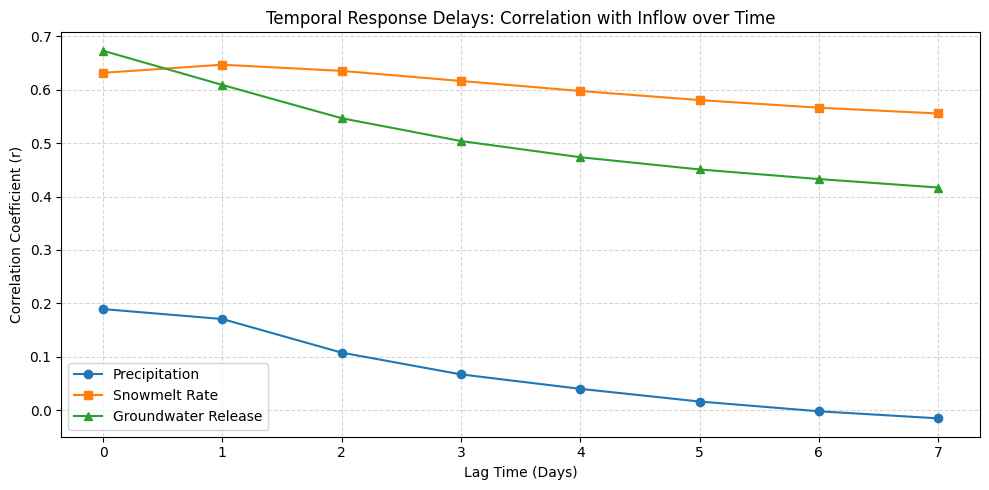

In [59]:
# Examine how previous days of rain and snowmelt correlate with current inflow
lags = range(0, 8)  # 0 to 7 days lag
lag_data = []

for lag in lags:
    lag_data.append({
        'Lag (Days)': lag,
        'Precipitation Corr': df['inflow'].corr(df['Precipitation'].shift(lag)),
        'Snowmelt Corr': df['inflow'].corr(df['Snowmelt_Rate'].shift(lag)),
        'Groundwater Corr': df['inflow'].corr(df['Groundwater_Release'].shift(lag))
    })

df_lags = pd.DataFrame(lag_data)

# Plot the cross-correlation profiles
plt.figure(figsize=(10, 5))
plt.plot(df_lags['Lag (Days)'], df_lags['Precipitation Corr'], marker='o', label='Precipitation')
plt.plot(df_lags['Lag (Days)'], df_lags['Snowmelt Corr'], marker='s', label='Snowmelt Rate')
plt.plot(df_lags['Lag (Days)'], df_lags['Groundwater Corr'], marker='^', label='Groundwater Release')

plt.title('Temporal Response Delays: Correlation with Inflow over Time')
plt.xlabel('Lag Time (Days)')
plt.ylabel('Correlation Coefficient (r)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

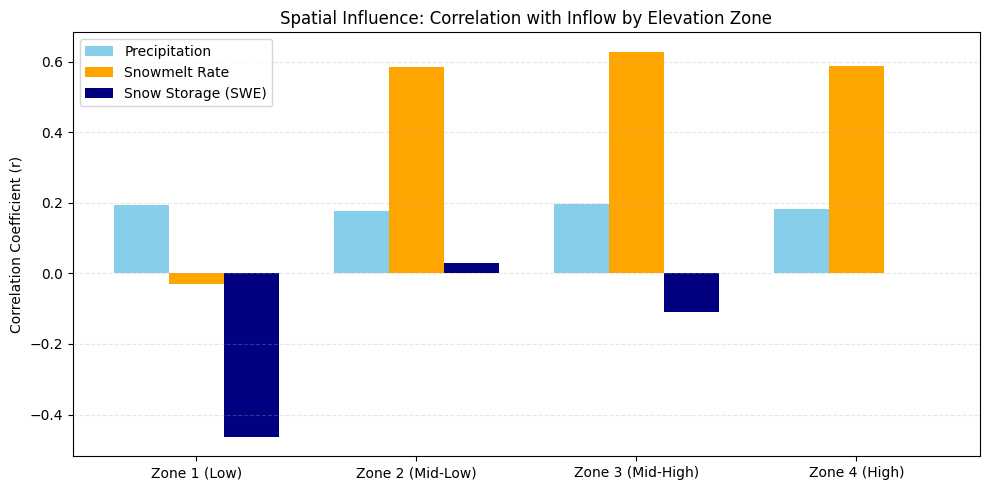

In [60]:
# Extract correlations of specific elevation zones to the main inflow target
rain_zones = [df['inflow'].corr(df[f'rr{i}']) for i in range(1, 5)]
melt_zones = [df['inflow'].corr(df[f'qsw{i}']) for i in range(1, 5)]
swe_zones = [df['inflow'].corr(df[f'swe{i}']) for i in range(1, 5)]

zone_indices = ['Zone 1 (Low)', 'Zone 2 (Mid-Low)', 'Zone 3 (Mid-High)', 'Zone 4 (High)']

x = np.arange(len(zone_indices))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, rain_zones, width, label='Precipitation', color='skyblue')
ax.bar(x, melt_zones, width, label='Snowmelt Rate', color='orange')
ax.bar(x + width, swe_zones, width, label='Snow Storage (SWE)', color='navy')

ax.set_title('Spatial Influence: Correlation with Inflow by Elevation Zone')
ax.set_xticks(x)
ax.set_xticklabels(zone_indices)
ax.set_ylabel('Correlation Coefficient (r)')
ax.grid(True, linestyle='--', alpha=0.3, axis='y')
ax.legend()
plt.tight_layout()
plt.show()

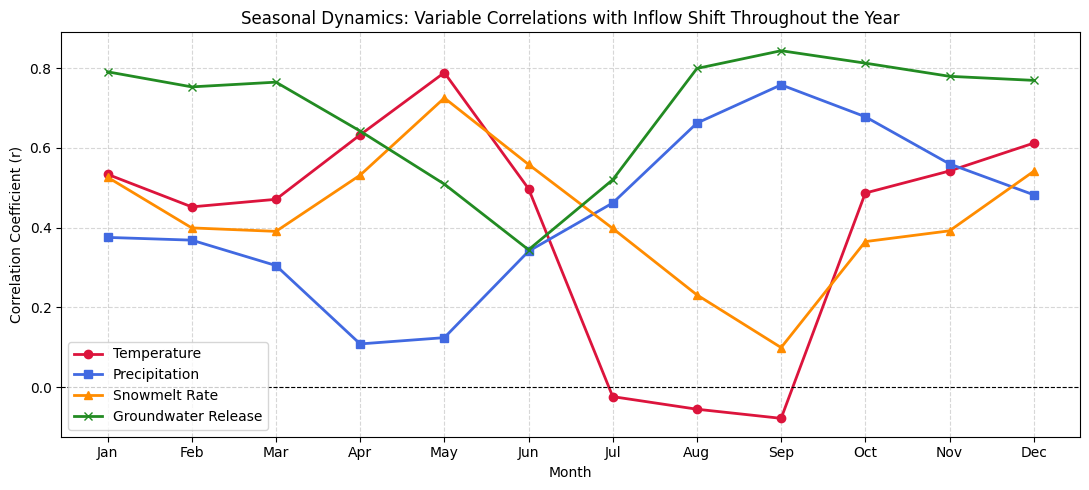

In [61]:
# 1. Calculate correlation coefficients for each month individually
monthly_corrs = []
for month in range(1, 13):
    month_df = df[df.index.month == month]
    monthly_corrs.append({
        'Month': month,
        'Temperature': month_df['inflow'].corr(month_df['Temperature']),
        'Precipitation': month_df['inflow'].corr(month_df['Precipitation']),
        'Snowmelt': month_df['inflow'].corr(month_df['Snowmelt_Rate']),
        'Groundwater': month_df['inflow'].corr(month_df['Groundwater_Release'])
    })

df_monthly_corr = pd.DataFrame(monthly_corrs)

# 2. Plot the seasonal variation of feature importance
plt.figure(figsize=(11, 5))
plt.plot(df_monthly_corr['Month'], df_monthly_corr['Temperature'], marker='o', color='crimson', linewidth=2, label='Temperature')
plt.plot(df_monthly_corr['Month'], df_monthly_corr['Precipitation'], marker='s', color='royalblue', linewidth=2, label='Precipitation')
plt.plot(df_monthly_corr['Month'], df_monthly_corr['Snowmelt'], marker='^', color='darkorange', linewidth=2, label='Snowmelt Rate')
plt.plot(df_monthly_corr['Month'], df_monthly_corr['Groundwater'], marker='x', color='forestgreen', linewidth=2, label='Groundwater Release')

plt.title('Seasonal Dynamics: Variable Correlations with Inflow Shift Throughout the Year')
plt.xlabel('Month')
plt.ylabel('Correlation Coefficient (r)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

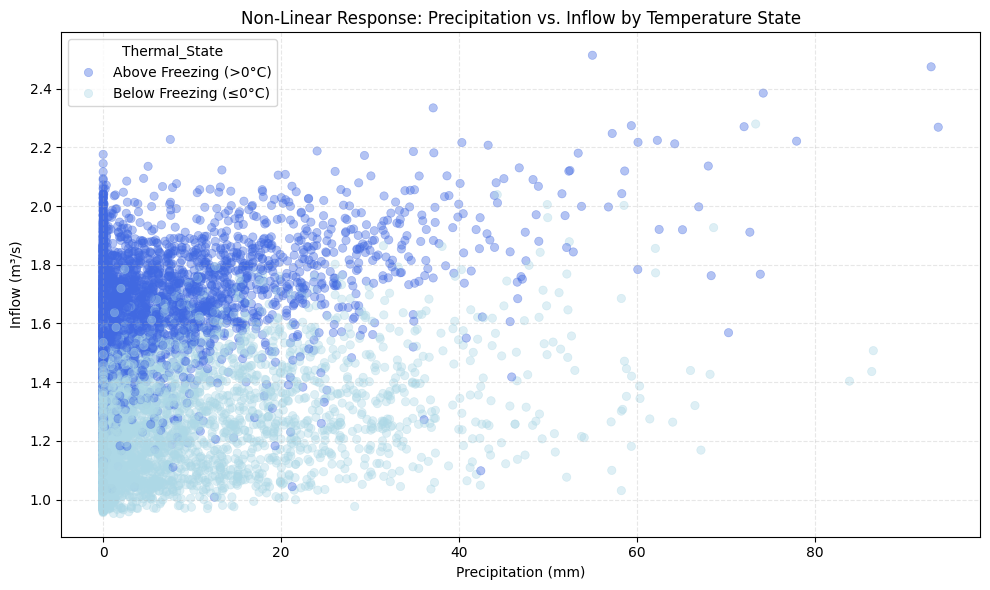

In [62]:
plt.figure(figsize=(10, 6))

# Create a masking column to separate days above and below freezing point
df['Thermal_State'] = np.where(df['Temperature'] > 0, 'Above Freezing (>0°C)', 'Below Freezing (≤0°C)')

# Plot Precipitation vs Inflow, color-coded by the freezing threshold
sns.scatterplot(
    data=df, 
    x='Precipitation', 
    y='inflow', 
    hue='Thermal_State', 
    palette={'Above Freezing (>0°C)': 'royalblue', 'Below Freezing (≤0°C)': 'lightblue'},
    alpha=0.4,
    edgecolor=None
)

plt.title('Non-Linear Response: Precipitation vs. Inflow by Temperature State')
plt.xlabel('Precipitation (mm)')
plt.ylabel('Inflow (m³/s)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

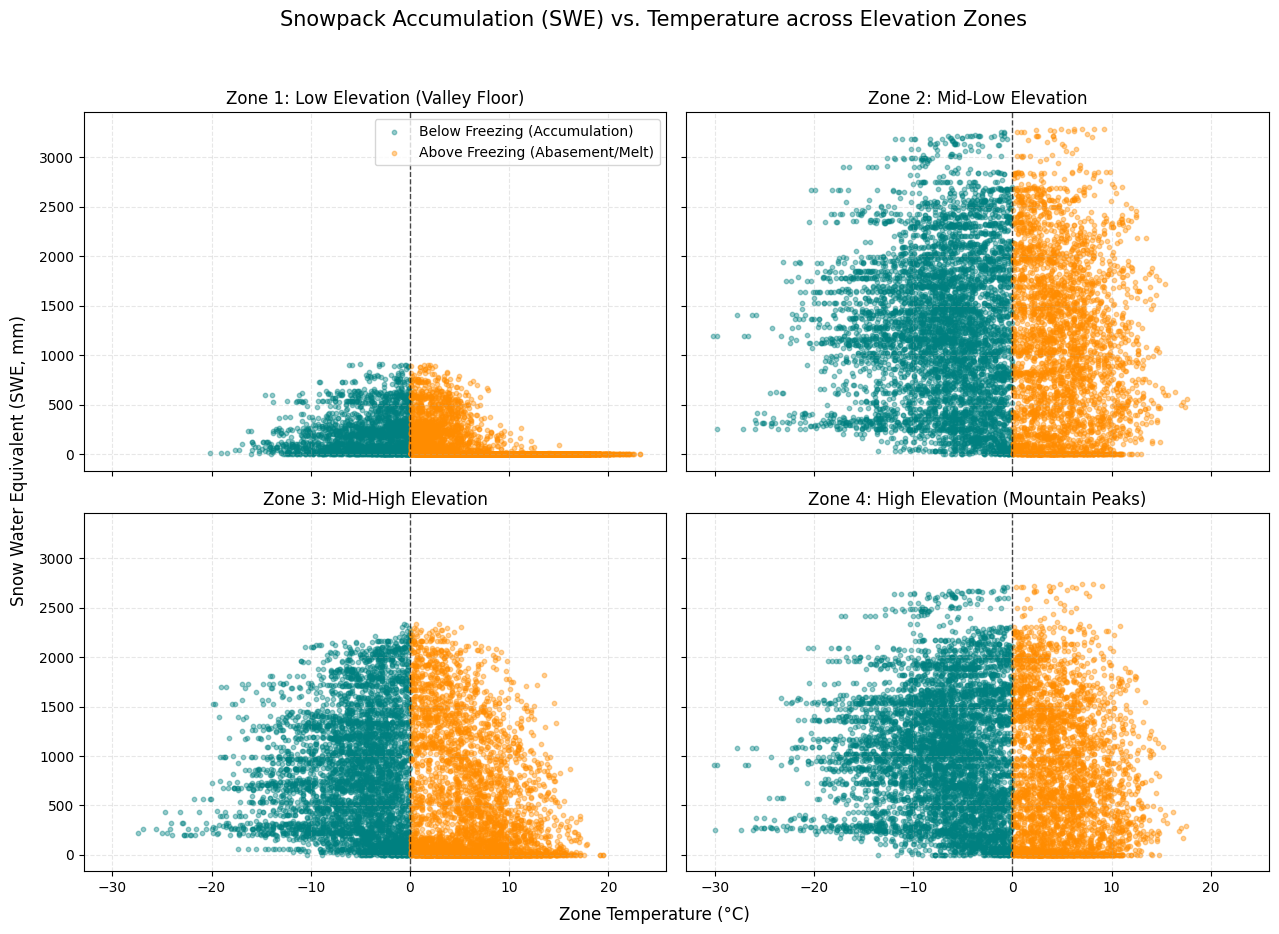

In [63]:
# 1. Set up a 2x2 grid for the four elevation zones
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

zone_titles = [
    'Zone 1: Low Elevation (Valley Floor)', 
    'Zone 2: Mid-Low Elevation', 
    'Zone 3: Mid-High Elevation', 
    'Zone 4: High Elevation (Mountain Peaks)'
]

# 2. Plot Temperature vs SWE for each individual zone
for i in range(4):
    zone_num = i + 1
    ax = axes[i]
    
    # Use a scatter plot color-coded by whether it's freezing or melting
    is_melting = df[f'tm{zone_num}'] > 0
    
    ax.scatter(
        df.loc[~is_melting, f'tm{zone_num}'], 
        df.loc[~is_melting, f'swe{zone_num}'], 
        color='teal', alpha=0.4, s=10, label='Below Freezing (Accumulation)'
    )
    ax.scatter(
        df.loc[is_melting, f'tm{zone_num}'], 
        df.loc[is_melting, f'swe{zone_num}'], 
        color='darkorange', alpha=0.4, s=10, label='Above Freezing (Abasement/Melt)'
    )
    
    # Visual cues for freezing threshold
    ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_title(zone_titles[i], fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # Only show legend on the first subplot to keep it clean
    if i == 0:
        ax.legend(loc='upper right', frameon=True)

# 3. Apply global labels and clean layout
fig.suptitle('Snowpack Accumulation (SWE) vs. Temperature across Elevation Zones', fontsize=15, y=0.95)
fig.text(0.5, 0.04, 'Zone Temperature (°C)', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'Snow Water Equivalent (SWE, mm)', va='center', rotation='vertical', fontsize=12)

plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.92])
plt.show()

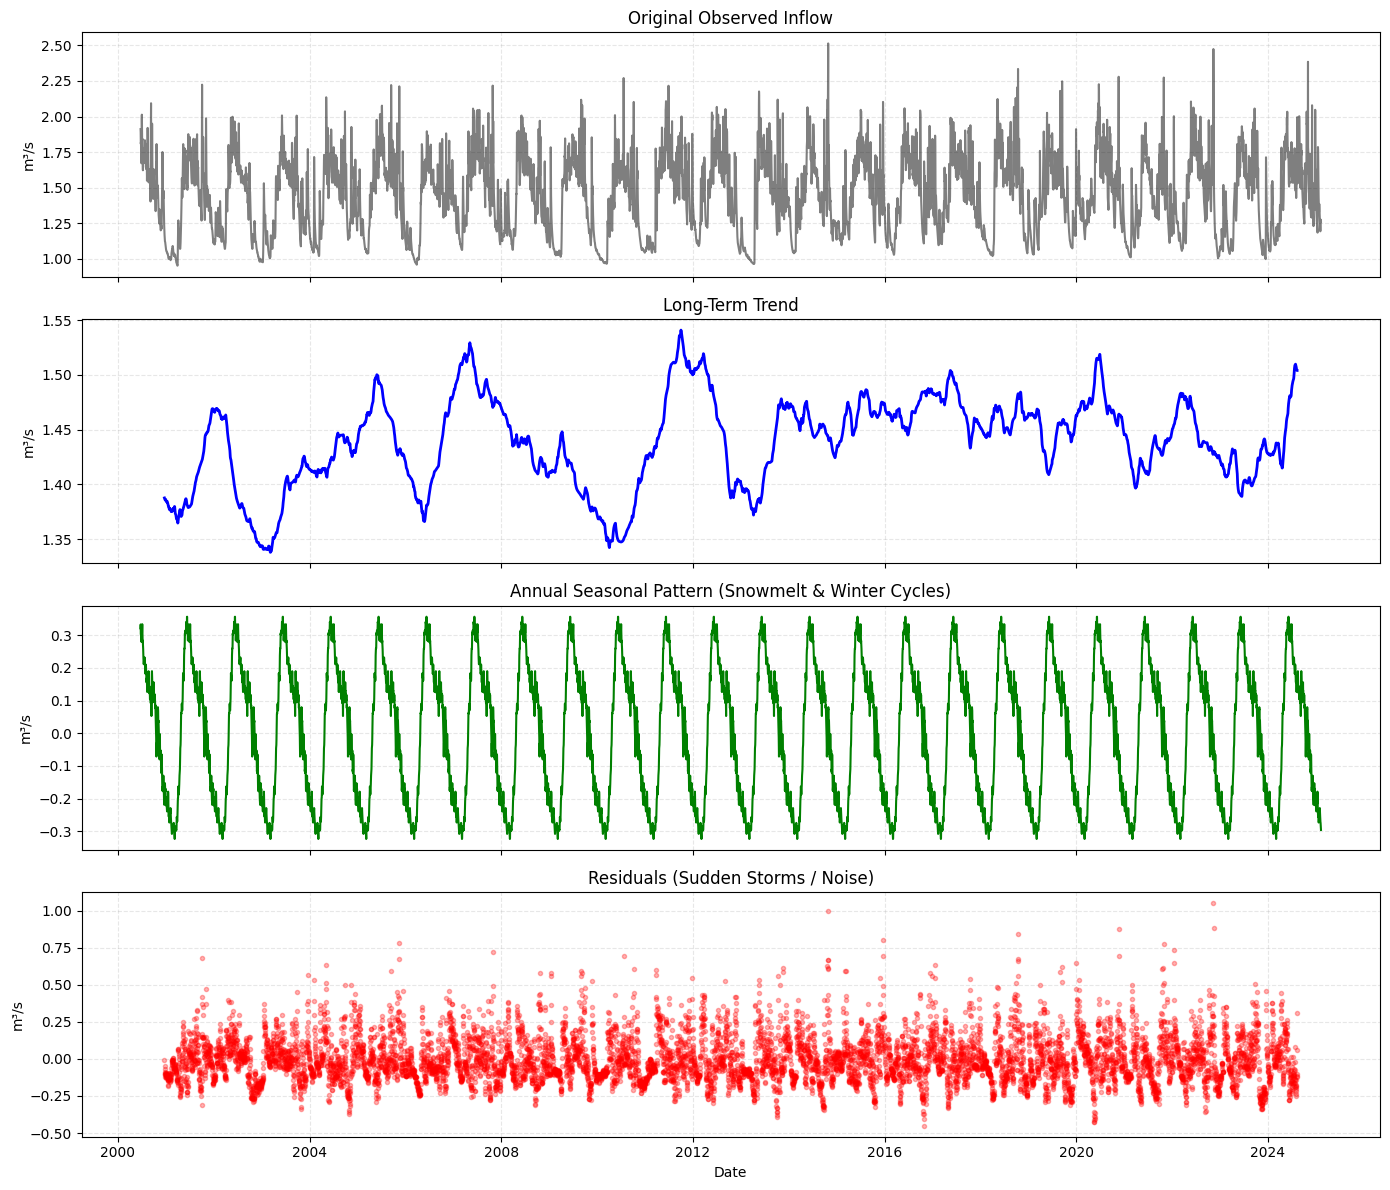

In [64]:
decomposition_inflow = seasonal_decompose(df['Inflow'], model='additive', period=365)

# Extract the components
trend = decomposition_inflow.trend
seasonal = decomposition_inflow.seasonal
residual = decomposition_inflow.resid

# Plot the separated components safely
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# 1. Observed
axes[0].plot(df['Inflow'], color='black', alpha=0.5)
axes[0].set_title('Original Observed Inflow')
axes[0].set_ylabel('m³/s')
axes[0].grid(True, linestyle='--', alpha=0.3)

# 2. Trend
axes[1].plot(trend, color='blue', linewidth=2)
axes[1].set_title('Long-Term Trend')
axes[1].set_ylabel('m³/s')
axes[1].grid(True, linestyle='--', alpha=0.3)

# 3. Seasonal
axes[2].plot(seasonal, color='green')
axes[2].set_title('Annual Seasonal Pattern (Snowmelt & Winter Cycles)')
axes[2].set_ylabel('m³/s')
axes[2].grid(True, linestyle='--', alpha=0.3)

# 4. Residuals (Fixed: changed style='.' to marker='.' and removed conflicting line styles)
axes[3].plot(residual, color='red', marker='.', linestyle='none', alpha=0.3)
axes[3].set_title('Residuals (Sudden Storms / Noise)')
axes[3].set_ylabel('m³/s')
axes[3].grid(True, linestyle='--', alpha=0.3)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

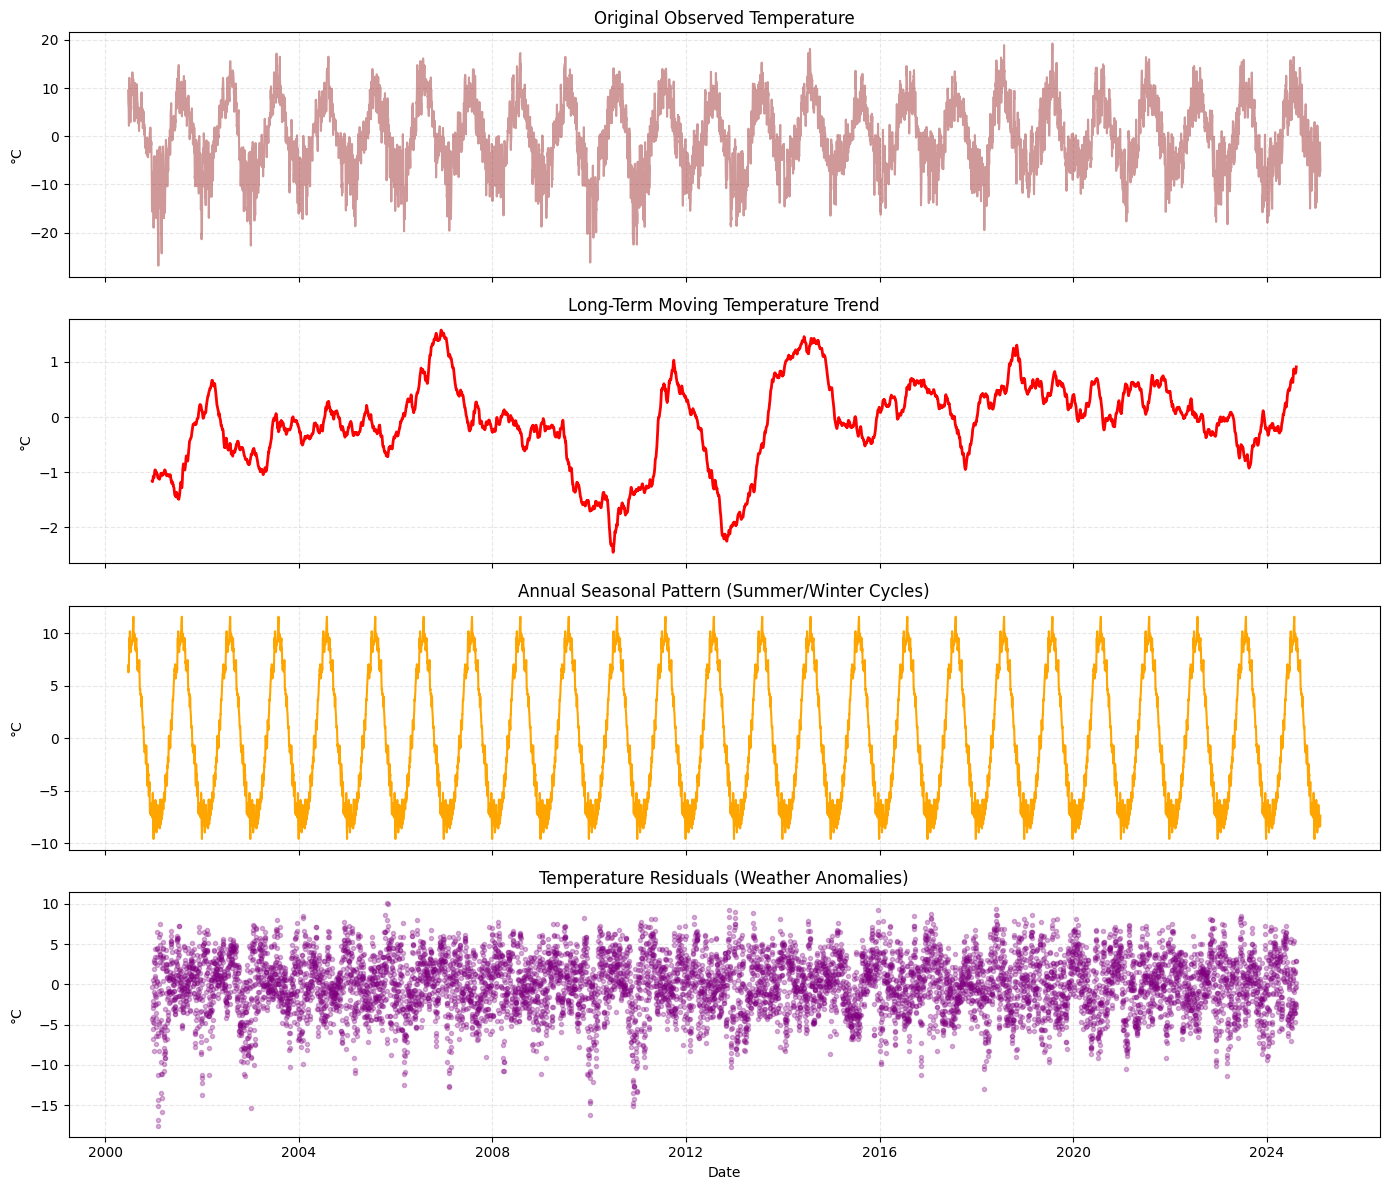

In [65]:
decomposition_temp = seasonal_decompose(df['Temperature'], model='additive', period=365)
trend_temp = decomposition_temp.trend
seasonal_temp = decomposition_temp.seasonal
residual_temp = decomposition_temp.resid

# 2. Plot the components
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Observed
axes[0].plot(df['Temperature'], color='darkred', alpha=0.4)
axes[0].set_title('Original Observed Temperature')
axes[0].set_ylabel('°C')
axes[0].grid(True, linestyle='--', alpha=0.3)

# Trend (Cleaned up: annual average line and legend removed)
axes[1].plot(trend_temp, color='red', linewidth=2)
axes[1].set_title('Long-Term Moving Temperature Trend')
axes[1].set_ylabel('°C')
axes[1].grid(True, linestyle='--', alpha=0.3)

# Seasonal
axes[2].plot(seasonal_temp, color='orange')
axes[2].set_title('Annual Seasonal Pattern (Summer/Winter Cycles)')
axes[2].set_ylabel('°C')
axes[2].grid(True, linestyle='--', alpha=0.3)

# Residuals
axes[3].plot(residual_temp, color='purple', marker='.', linestyle='none', alpha=0.3)
axes[3].set_title('Temperature Residuals (Weather Anomalies)')
axes[3].set_ylabel('°C')
axes[3].grid(True, linestyle='--', alpha=0.3)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

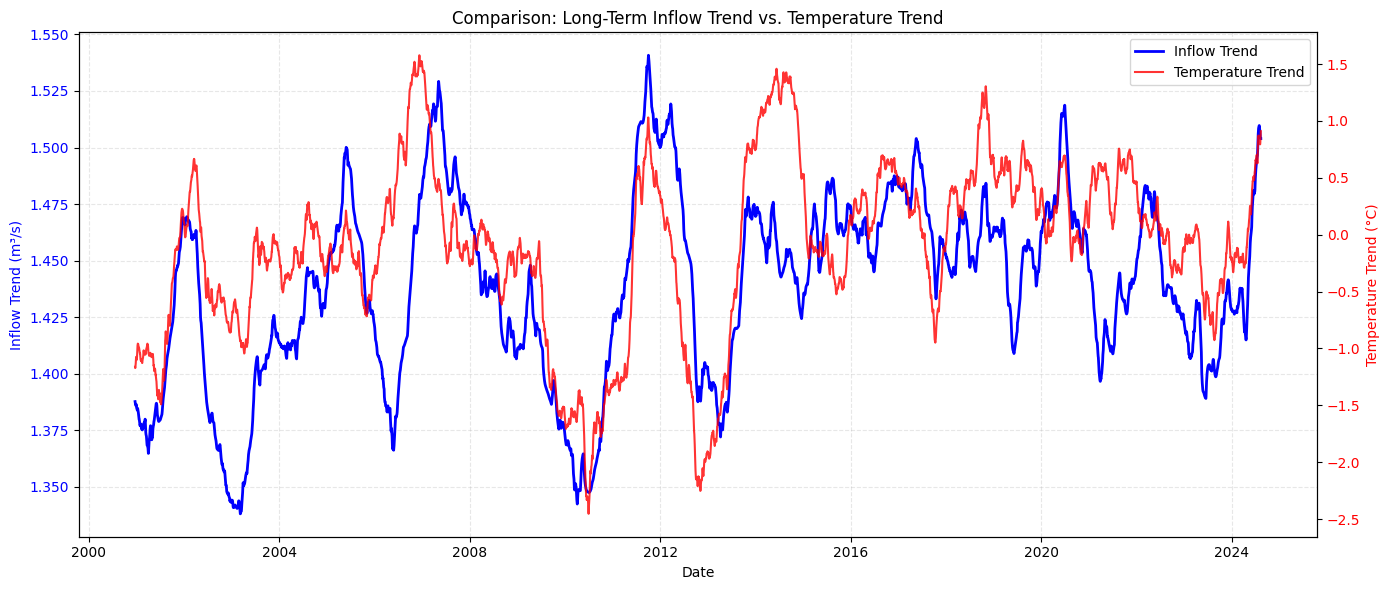

In [66]:

# 2. Set up the figure
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot Inflow Trend on the left axis
color1 = 'blue'
ax1.plot(decomposition_inflow.trend, color=color1, linewidth=2, label='Inflow Trend')
ax1.set_xlabel('Date')
ax1.set_ylabel('Inflow Trend (m³/s)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.3)

# Create a twin axis sharing the x-axis for Temperature
ax2 = ax1.twinx()
color2 = 'red'
ax2.plot(decomposition_temp.trend, color=color2, linewidth=1.5, alpha=0.8, label='Temperature Trend')
ax2.set_ylabel('Temperature Trend (°C)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Comparison: Long-Term Inflow Trend vs. Temperature Trend')
plt.tight_layout()
plt.show()

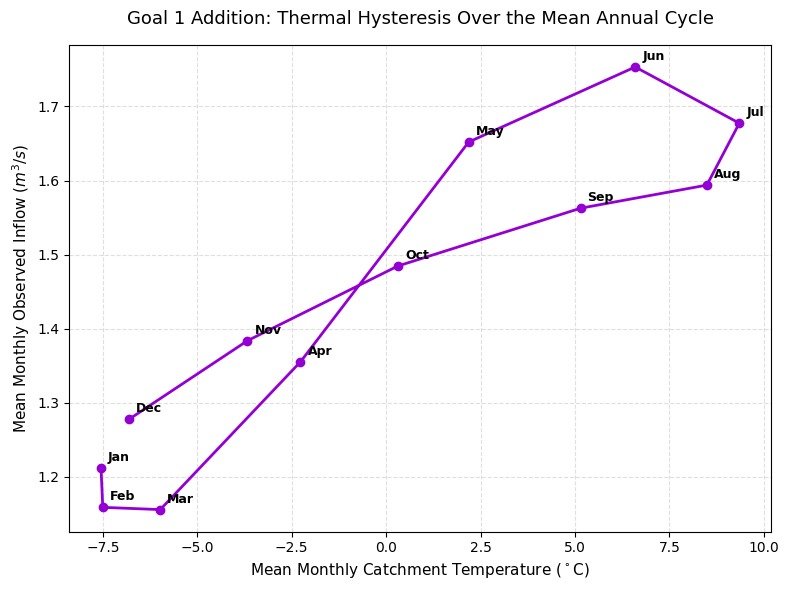

In [67]:
# 1. Compute multi-year mean values grouped by month
monthly_climatology = df.groupby(df.index.month)[['Temperature', 'Inflow']].mean()

# 2. Plot the seasonal trajectory loop
plt.figure(figsize=(8, 6))
plt.plot(monthly_climatology['Temperature'], monthly_climatology['Inflow'], marker='o', linewidth=2, color='darkviolet', label='Annual Cycle Path')

# 3. Label each monthly coordinate
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for i, name in enumerate(month_labels):
    plt.annotate(
        name, 
        (monthly_climatology['Temperature'].iloc[i], monthly_climatology['Inflow'].iloc[i]),
        textcoords="offset points", 
        xytext=(5, 5), 
        ha='left', 
        fontsize=9, 
        fontweight='bold'
    )

plt.title('Goal 1 Addition: Thermal Hysteresis Over the Mean Annual Cycle', fontsize=13, pad=15)
plt.xlabel('Mean Monthly Catchment Temperature ($^\circ$C)', fontsize=11)
plt.ylabel('Mean Monthly Observed Inflow ($m^3/s$)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

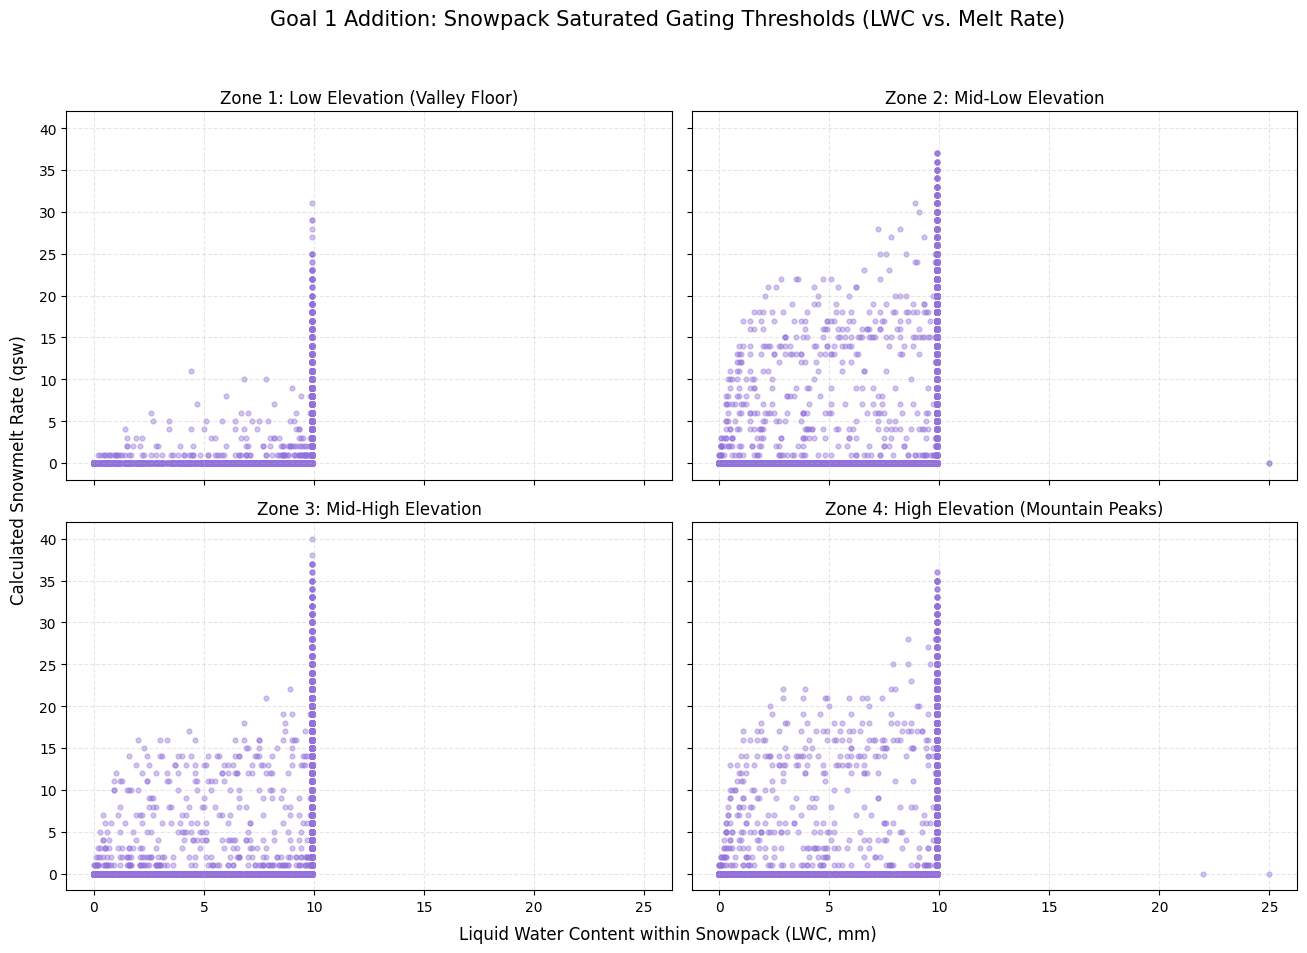

In [68]:
# 1. Establish a 2x2 grid corresponding to the four physical elevation tiers
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

zone_titles = [
    'Zone 1: Low Elevation (Valley Floor)', 
    'Zone 2: Mid-Low Elevation', 
    'Zone 3: Mid-High Elevation', 
    'Zone 4: High Elevation (Mountain Peaks)'
]

# 2. Iterate through each zone to check liquid storage capacity boundaries
for i in range(4):
    zone_num = i + 1
    ax = axes[i]
    
    # Isolate time periods where a physical snowpack actually exists
    has_snowpack = df[f'swe{zone_num}'] > 0
    
    ax.scatter(
        df.loc[has_snowpack, f'lwc{zone_num}'], 
        df.loc[has_snowpack, f'qsw{zone_num}'], 
        color='mediumpurple', alpha=0.4, s=12
    )
    
    ax.set_title(zone_titles[i], fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)

# 3. Structural titles and baseline axis labels
fig.suptitle('Goal 1 Addition: Snowpack Saturated Gating Thresholds (LWC vs. Melt Rate)', fontsize=15, y=0.96)
fig.text(0.5, 0.03, 'Liquid Water Content within Snowpack (LWC, mm)', ha='center', fontsize=12)
fig.text(0.03, 0.5, 'Calculated Snowmelt Rate (qsw)', va='center', rotation='vertical', fontsize=12)

plt.tight_layout(rect=[0.04, 0.04, 0.96, 0.93])
plt.show()

In [69]:

df['Inflow_Lag1'] = df['Inflow'].shift(1)
df['Inflow_Lag2'] = df['Inflow'].shift(2)
df['Inflow_Lag3'] = df['Inflow'].shift(3)

# 2. Exogenous Lags (Transit Delays)
df['Precip_Lag1'] = df['Precipitation'].shift(1)
df['Precip_Lag2'] = df['Precipitation'].shift(2)
df['Temp_Lag1'] = df['Temperature'].shift(1)
df['Snowmelt_Lag1'] = df['Snowmelt_Rate'].shift(1)

# 3. Rolling Window Aggregates (Catchment Accumulation Storage)
df['Precip_Roll3'] = df['Precipitation'].rolling(window=3).mean()
df['Precip_Roll7'] = df['Precipitation'].rolling(window=7).mean()
df['Temp_Roll3'] = df['Temperature'].rolling(window=3).mean()

# Isolate lookback-truncated clean data for modeling steps
df_model = df.dropna().copy()

print(f"New feature matrix constructed. Shape: {df_model.shape}")

New feature matrix constructed. Shape: (8992, 43)


In [70]:
print("--- Augmented Dickey-Fuller Test on Target Variable (Inflow) ---")
adf_result = adfuller(df_model['Inflow'])

print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4e}")
print("Critical Values Verification:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

if adf_result[1] <= 0.05:
    print("\nConclusion: p-value <= 0.05. Reject null hypothesis. Series is stationary.")
else:
    print("\nConclusion: p-value > 0.05. Fail to reject null hypothesis. Series requires differencing.")

--- Augmented Dickey-Fuller Test on Target Variable (Inflow) ---
ADF Statistic: -7.8121
p-value: 7.0237e-12
Critical Values Verification:
   1%: -3.4311
   5%: -2.8619
   10%: -2.5669

Conclusion: p-value <= 0.05. Reject null hypothesis. Series is stationary.


In [71]:
# Temporal split boundary
split_date = '2020-01-01'

train_df = df_model.loc[df_model.index < split_date]
test_df = df_model.loc[df_model.index >= split_date]

# Consolidate exact array keys
new_features_list = [
    'Inflow_Lag1', 'Inflow_Lag2', 'Inflow_Lag3',
    'Precip_Lag1', 'Precip_Lag2', 'Temp_Lag1', 'Snowmelt_Lag1',
    'Precip_Roll3', 'Precip_Roll7', 'Temp_Roll3',
    'Temperature', 'Precipitation'
]

X_train, y_train = train_df[new_features_list], train_df['Inflow']
X_test, y_test = test_df[new_features_list], test_df['Inflow']

print(f"X_train array shape: {X_train.shape} | X_test array shape: {X_test.shape}")

X_train array shape: (7126, 12) | X_test array shape: (1866, 12)


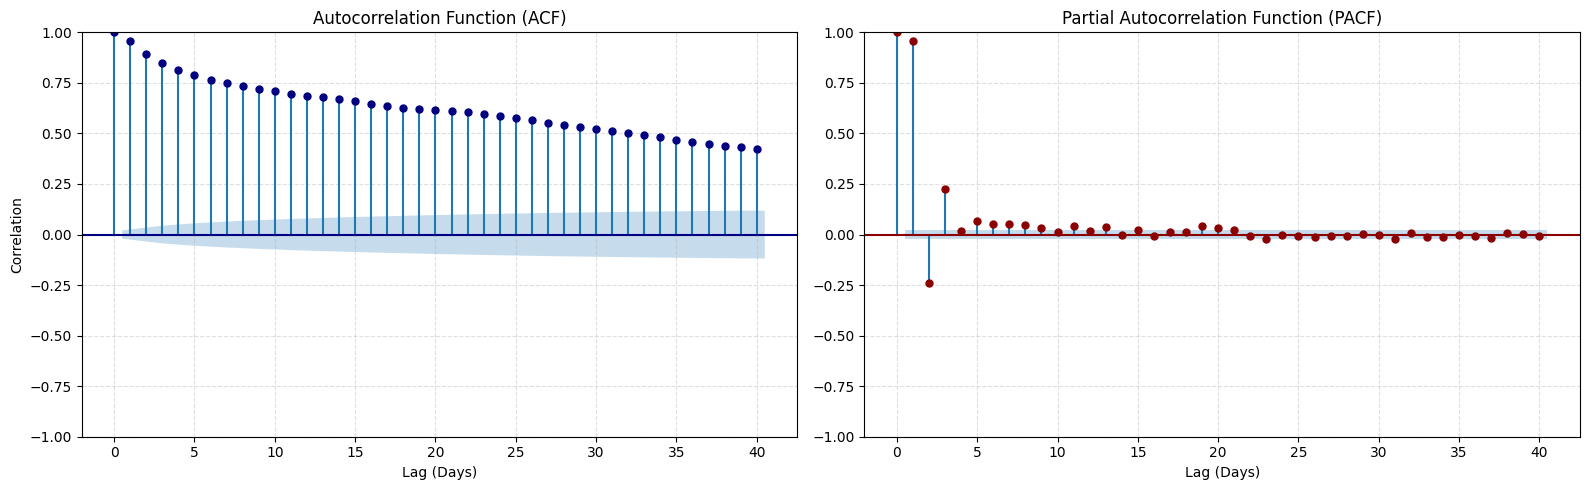

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Plot the Autocorrelation Function (ACF) to evaluate MA (q) terms
plot_acf(df_model['Inflow'], lags=40, ax=axes[0], color='navy')
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lag (Days)')
axes[0].set_ylabel('Correlation')
axes[0].grid(True, linestyle='--', alpha=0.4)

# 2. Plot the Partial Autocorrelation Function (PACF) to evaluate AR (p) terms
plot_pacf(df_model['Inflow'], lags=40, ax=axes[1], color='darkred', method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].set_xlabel('Lag (Days)')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [73]:
y_pred_baseline = X_test['Inflow_Lag1']

# Calculate baseline performance metrics
mae_base = mean_absolute_error(y_test, y_pred_baseline)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print("--- Naive Baseline Benchmark Performance ---")
print(f"Baseline Mean Absolute Error (MAE): {mae_base:.3f} m³/s")
print(f"Baseline Root Mean Squared Error (RMSE): {rmse_base:.3f} m³/s")

--- Naive Baseline Benchmark Performance ---
Baseline Mean Absolute Error (MAE): 0.049 m³/s
Baseline Root Mean Squared Error (RMSE): 0.084 m³/s


In [74]:
arima_model = ARIMA(y_train, order=(3, 0, 0))
arima_results = arima_model.fit()

# 2. Forecast out over the test period length
# Dynamic=False means it uses true historical values as they become available day-by-day
y_pred_arima = arima_results.predict(start=X_test.index[0], end=X_test.index[-1])

# 3. Calculate metrics
mae_arima = mean_absolute_error(y_test, y_pred_arima)
rmse_arima = np.sqrt(mean_squared_error(y_test, y_pred_arima))

print("--- Pure ARIMA(3,0,0) Performance ---")
print(f"ARIMA MAE: {mae_arima:.3f} m³/s")
print(f"ARIMA RMSE: {rmse_arima:.3f} m³/s")

c:\Users\bmdah\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\bmdah\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\bmdah\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


--- Pure ARIMA(3,0,0) Performance ---
ARIMA MAE: 0.218 m³/s
ARIMA RMSE: 0.260 m³/s


In [75]:
# 1. Select the two distinct physical water drivers to eliminate extreme multicollinearity
exog_cols_clean = ['Precipitation', 'Snowmelt_Rate']

# 2. Hard-clean the training data using just these two features
train_clean = train_df[['Inflow'] + exog_cols_clean].dropna()
y_train_clean = train_clean['Inflow']
X_train_clean = train_clean[exog_cols_clean]

# 3. Hard-clean the test data the exact same way
test_clean = test_df[['Inflow'] + exog_cols_clean].dropna()
y_test_clean = test_clean['Inflow']
X_test_clean = test_clean[exog_cols_clean]

# 4. Fit the ARIMA model with the streamlined feature set
arimax_model = ARIMA(y_train_clean, exog=X_train_clean.values, order=(3, 0, 0))
arimax_results = arimax_model.fit()

# 5. Forecast over the clean test periods
y_pred_arimax = arimax_results.predict(
    start=X_test_clean.index[0], 
    end=X_test_clean.index[-1], 
    exog=X_test_clean.values
)

# 6. Calculate performance metrics
mae_arimax = mean_absolute_error(y_test_clean, y_pred_arimax)
rmse_arimax = np.sqrt(mean_squared_error(y_test_clean, y_pred_arimax))

print("--- Streamlined ARIMAX(3,0,0) Performance ---")
print(f"ARIMAX MAE: {mae_arimax:.3f} m³/s")
print(f"ARIMAX RMSE: {rmse_arimax:.3f} m³/s")

# 7. Print the summary to verify the nan values are gone
print(arimax_results.summary())

c:\Users\bmdah\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\bmdah\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\bmdah\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\bmdah\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


--- Streamlined ARIMAX(3,0,0) Performance ---
ARIMAX MAE: 0.193 m³/s
ARIMAX RMSE: 0.230 m³/s
                               SARIMAX Results                                
Dep. Variable:                 Inflow   No. Observations:                 7126
Model:                 ARIMA(3, 0, 0)   Log Likelihood                9577.621
Date:                Tue, 26 May 2026   AIC                         -19141.241
Time:                        15:11:54   BIC                         -19093.141
Sample:                    06-28-2000   HQIC                        -19124.681
                         - 12-31-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3924      0.013    105.566      0.000       1.367       1.418
x1             0.0026   3.17e-05     8

--- HISTORICAL PERFORMANCE SUMMARY ---
               Model Type  MAE (m³/s)  RMSE (m³/s)
           Naive Baseline    0.048713     0.084456
 Pure ARIMA (Inflow Only)    0.217606     0.259677
ARIMAX (Inflow + Weather)    0.193182     0.230362


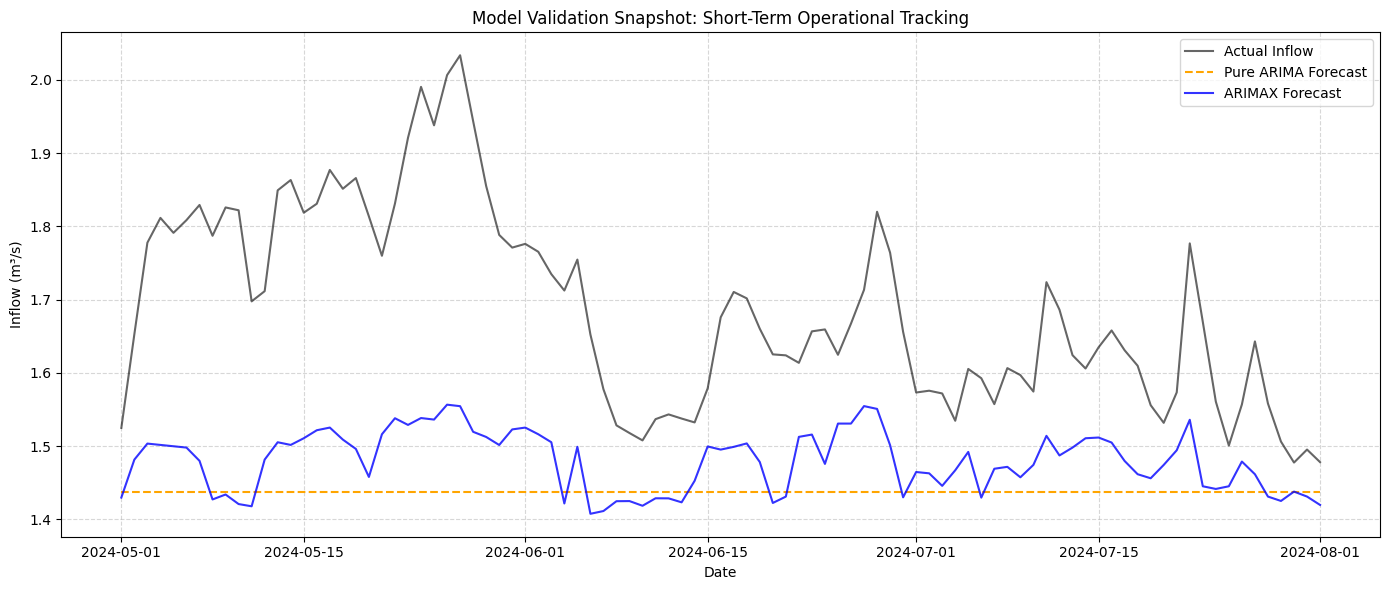

In [76]:
# --- GOAL 3: HISTORICAL MODEL COMPARISON & VALIDATION ---

# 1. Compile validation metrics into a single comparison DataFrame
performance_summary = pd.DataFrame({
    'Model Type': ['Naive Baseline', 'Pure ARIMA (Inflow Only)', 'ARIMAX (Inflow + Weather)'],
    'MAE (m³/s)': [mae_base, mae_arima, mae_arimax],
    'RMSE (m³/s)': [rmse_base, rmse_arima, rmse_arimax]
})

print("--- HISTORICAL PERFORMANCE SUMMARY ---")
print(performance_summary.to_string(index=False))

# 2. Visualize a 3-month summer validation window to contrast model behaviors
plt.figure(figsize=(14, 6))
snapshot_start, snapshot_end = '2024-05-01', '2024-08-01'

plt.plot(y_test_clean.loc[snapshot_start:snapshot_end], label='Actual Inflow', color='black', alpha=0.6)
plt.plot(y_pred_arima.loc[snapshot_start:snapshot_end], label='Pure ARIMA Forecast', color='orange', linestyle='--')
plt.plot(y_pred_arimax.loc[snapshot_start:snapshot_end], label='ARIMAX Forecast', color='blue', alpha=0.8)

plt.title('Model Validation Snapshot: Short-Term Operational Tracking')
plt.ylabel('Inflow (m³/s)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

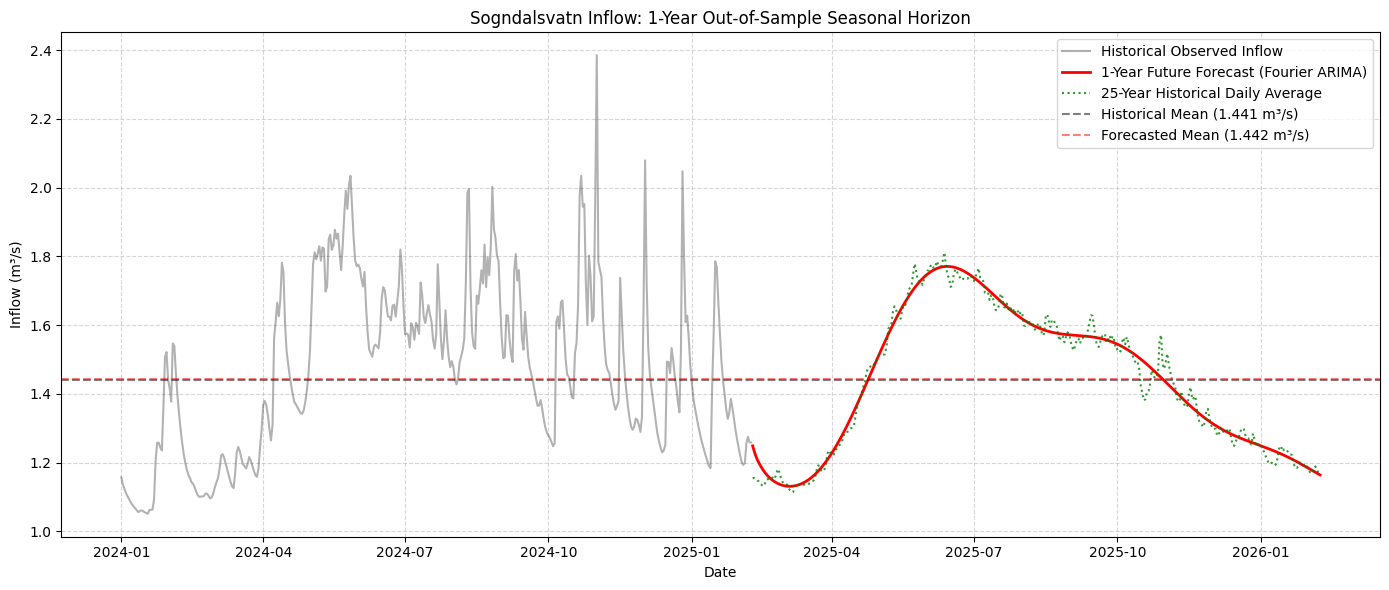

In [77]:
# --- GOAL 3: LONG-TERM CLIMATOLOGICAL PROJECTION ---

# 1. Enforce strict daily frequency and fill gaps on the full series
df_clean = df.asfreq('D')
df_clean['Inflow'] = df_clean['Inflow'].ffill()

# 2. Generate seasonal features for the full historical period
exog_train = generate_fourier_terms(df_clean.index)

# 3. Fit ARIMA(3, 0, 0) with Fourier terms on all available data
fourier_arima_model = ARIMA(df_clean['Inflow'], exog=exog_train, order=(3, 0, 0)).fit()

# 4. Create a 365-day future index past the end of the dataset
future_horizon = 365
future_index = pd.date_range(
    start=df_clean.index[-1] + pd.Timedelta(days=1), 
    periods=future_horizon, 
    freq='D'
)
exog_future = generate_fourier_terms(future_index)

# 5. Generate the out-of-sample forecast
future_forecast_values = fourier_arima_model.forecast(steps=future_horizon, exog=exog_future)
y_future_forecast = pd.Series(future_forecast_values.values, index=future_index)

# 6. Calculate Baseline Comparison Averages
historical_overall_mean = df_clean['Inflow'].mean()
forecast_overall_mean = y_future_forecast.mean()

# Compute 25-year daily average pattern
historical_climatology = df_clean.groupby(df_clean.index.dayofyear)['Inflow'].mean()
y_historical_climatology = pd.Series(future_index.dayofyear.map(historical_climatology).values, index=future_index)

# 7. Generate final future horizon plot
fig, ax = plt.subplots(figsize=(14, 6))
historical_context = df_clean['Inflow'].loc['2024-01-01':]

ax.plot(historical_context, label='Historical Observed Inflow', color='black', alpha=0.3)
ax.plot(y_future_forecast, label='1-Year Future Forecast (Fourier ARIMA)', color='red', linewidth=2)
ax.plot(y_historical_climatology, label='25-Year Historical Daily Average', color='green', linestyle=':', alpha=0.8)

ax.axhline(historical_overall_mean, color='black', linestyle='--', alpha=0.5, label=f'Historical Mean ({historical_overall_mean:.3f} m³/s)')
ax.axhline(forecast_overall_mean, color='red', linestyle='--', alpha=0.5, label=f'Forecasted Mean ({forecast_overall_mean:.3f} m³/s)')

ax.set_title('Sogndalsvatn Inflow: 1-Year Out-of-Sample Seasonal Horizon')
ax.set_ylabel('Inflow (m³/s)')
ax.set_xlabel('Date')
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()